# Projeto de Análise de Dados de Fórmula 1

## Disciplina: C111  
**Instituição:** Inatel  
**Alunos:** Júlio César Corrêa, Petterson Ikaro Bento de Sousa e Lucas da Silva Pádua  

Análise de dados históricos da Fórmula 1 (1950-2020) com dataset do Kaggle: [Formula 1 Dataset](https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020).

---

## Ferramentas

- **Python**
- Bibliotecas: `pandas`, `numpy`, `matplotlib`, `os`.

---

# Importar Bibliotecas Necessárias
Importar pandas, numpy, matplotlib e os para análise e visualização de dados.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## Carregar Conjuntos de Dados
Carregue todos os conjuntos de dados necessários (por exemplo, circuits.csv, races.csv, lap_times.csv) usando pandas.

In [3]:
# Caminho para a pasta de dados
DATA_PATH = os.path.join(os.getcwd(), 'data')

# Carregamento dos datasets
circuits = pd.read_csv(os.path.join(DATA_PATH, 'circuits.csv'))
constructors = pd.read_csv(os.path.join(DATA_PATH, 'constructors.csv'))
constructor_results = pd.read_csv(os.path.join(DATA_PATH, 'constructor_results.csv'))
constructor_standings = pd.read_csv(os.path.join(DATA_PATH, 'constructor_standings.csv'))
drivers = pd.read_csv(os.path.join(DATA_PATH, 'drivers.csv'))
driver_standings = pd.read_csv(os.path.join(DATA_PATH, 'driver_standings.csv'))
lap_times = pd.read_csv(os.path.join(DATA_PATH, 'lap_times.csv'))
pit_stops = pd.read_csv(os.path.join(DATA_PATH, 'pit_stops.csv'))
qualifying = pd.read_csv(os.path.join(DATA_PATH, 'qualifying.csv'))
races = pd.read_csv(os.path.join(DATA_PATH, 'races.csv'))
results = pd.read_csv(os.path.join(DATA_PATH, 'results.csv'))
seasons = pd.read_csv(os.path.join(DATA_PATH, 'seasons.csv'))
status = pd.read_csv(os.path.join(DATA_PATH, 'status.csv'))

## Pergunta 1: Qual a quantidade de corridas por temporada desde 1981?

In [5]:
# Pegando corridas depois de 1981
racesAfter81 = races[races['year'] >= 1981]

# Agrupando as corridas por ano
corridasPorAno = racesAfter81.groupby('year')['raceId'].count().reset_index()

corridasPorAno.columns = ['ano', 'qtd_corridas']
print("Corridas desde 1981:")
print(corridasPorAno)

Corridas desde 1981:
     ano  qtd_corridas
0   1981            15
1   1982            16
2   1983            15
3   1984            16
4   1985            16
5   1986            16
6   1987            16
7   1988            16
8   1989            16
9   1990            16
10  1991            16
11  1992            16
12  1993            16
13  1994            16
14  1995            17
15  1996            16
16  1997            17
17  1998            16
18  1999            16
19  2000            17
20  2001            17
21  2002            17
22  2003            16
23  2004            18
24  2005            19
25  2006            18
26  2007            17
27  2008            18
28  2009            17
29  2010            19
30  2011            19
31  2012            20
32  2013            19
33  2014            19
34  2015            19
35  2016            21
36  2017            20
37  2018            21
38  2019            21
39  2020            17
40  2021            22
41  2022     

## Pergunta 2: Top 10 Pilotos com Mais Vitórias

In [6]:
# Pegando as vitórias e o nome dos piltos ganhadores
vitorias = results[results['positionOrder'] == 1]
vitorias_por_piloto = vitorias['driverId'].value_counts()

# Criando DataFrame
top_vitorias = vitorias_por_piloto.head(10).reset_index()
top_vitorias.columns = ['driverId', 'qtd_vitorias']

# Juntando com dataset de Drivers para pega o nome
top_pilotos = top_vitorias.merge(drivers, on='driverId')
top_pilotos['nome_completo'] = top_pilotos['forename'] + ' ' + top_pilotos['surname']

print("Top 10 ganhadores da história:")
print(top_pilotos[['nome_completo', 'qtd_vitorias']])

Top 10 ganhadores da história:
        nome_completo  qtd_vitorias
0      Lewis Hamilton           105
1  Michael Schumacher            91
2      Max Verstappen            63
3    Sebastian Vettel            53
4         Alain Prost            51
5        Ayrton Senna            41
6     Fernando Alonso            32
7       Nigel Mansell            31
8      Jackie Stewart            27
9          Niki Lauda            25


## Pergunta 3:  Qual equipe teve mais vitórias?

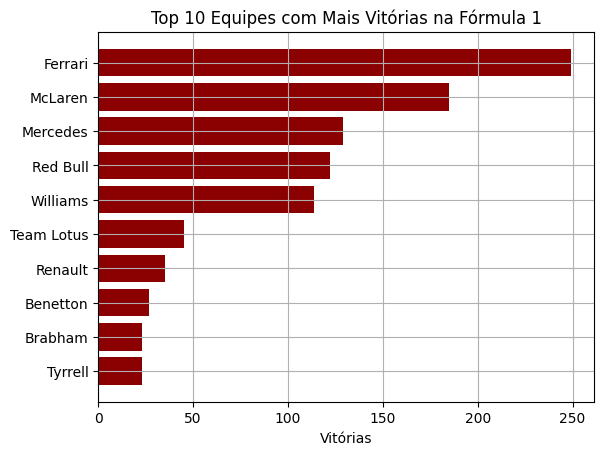

In [7]:
# Pegando as vitorias das equipes
vitorias_por_equipe = vitorias['constructorId'].value_counts()

# Criando o DataFrame de vitórias
top_equipe_vitorias = vitorias_por_equipe.reset_index()
top_equipe_vitorias.columns = ['constructorId', 'qtd_vitorias']

# Juntando com os dados dos constructors para pegar o nome
top_equipes = top_equipe_vitorias.merge(constructors, on='constructorId')

# Selecionando o Top 10
top10_equipes = top_equipes.head(10)

# Criando o gráfico
plt.barh(top10_equipes['name'], top10_equipes['qtd_vitorias'], color='darkred')
plt.xlabel('Vitórias')
plt.title('Top 10 Equipes com Mais Vitórias na Fórmula 1')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## Pergunta 4: Quais países tiveram a maior quantidade de vitórias?

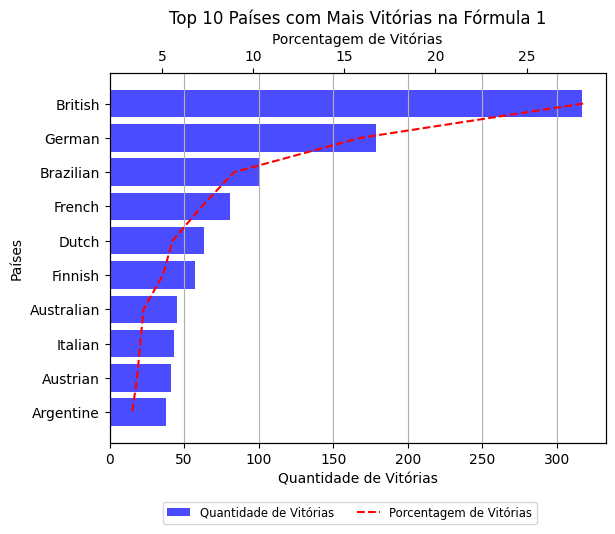

In [22]:
# Pegando as vitórias e o país dos pilotos ganhadores
vitorias = results[results['positionOrder'] == 1]
# Juntando com o dataset de drivers para pegar o país
vitorias_por_pais = vitorias.merge(drivers, on='driverId')  

# Agrupando por país e contando as vitórias
vitorias_por_pais = vitorias_por_pais.groupby('nationality').size().sort_values(ascending=False)

# Calculando a porcentagem de vitórias
vitorias_por_pais_percentual = (vitorias_por_pais / vitorias_por_pais.sum()) * 100

# Criando o DataFrame para exibição
dados_vitorias = pd.DataFrame({
  'nacionalidade': vitorias_por_pais.index,
  'qtd_vitorias': vitorias_por_pais.values,
  'percentual_vitorias': vitorias_por_pais_percentual.values
}).head(10)


# Criando o gráfico
fig, ax1 = plt.subplots()
# Gráfico de barras para a quantidade de vitórias
ax1.barh(dados_vitorias['nacionalidade'], dados_vitorias['qtd_vitorias'], color='blue', alpha=0.7, label='Quantidade de Vitórias')
ax1.set_xlabel('Quantidade de Vitórias')
ax1.set_ylabel('Países')
ax1.set_title('Top 10 Países com Mais Vitórias na Fórmula 1')
ax1.invert_yaxis()  # Primeiro lugar no topo
ax1.grid(True, axis='x')
# Adicionando um eixo secundário para a porcentagem de vitórias
ax2 = ax1.twiny()
ax2.plot(dados_vitorias['percentual_vitorias'], dados_vitorias['nacionalidade'], 'r--', label='Porcentagem de Vitórias')
ax2.set_xlabel('Porcentagem de Vitórias')
# Adicionando legenda
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.001), ncol=2, fontsize='small')
plt.show()


## Pergunta 5: Qual a média de voltas por corrida?

In [23]:
# Calculando o número máximo de voltas por corrida (ou seja a última volta é a quantidade de total de voltas)
voltas_por_corrida = lap_times.groupby('raceId')['lap'].max()
# Juntando os dados de voltas com o dataset de corridas para obter os circuitos
voltas_com_circuito = voltas_por_corrida.reset_index().merge(races[['raceId', 'circuitId']], on='raceId')

# Calculando a média de voltas por circuito
media_voltas_por_circuito = voltas_com_circuito.groupby('circuitId')['lap'].mean().reset_index()

# Calculando estatísticas descritivas
media_geral_voltas = media_voltas_por_circuito['lap'].mean()
mediana_voltas = media_voltas_por_circuito['lap'].median()
desvio_padrao_voltas = media_voltas_por_circuito['lap'].std()

# Exibindo as estatísticas
print("\nEstatísticas das voltas por circuito:")
print(f"Média Geral de Voltas: {media_geral_voltas:.2f}")
print(f"Mediana de Voltas: {mediana_voltas:.2f}")
print(f"Desvio Padrão de Voltas: {desvio_padrao_voltas:.2f}")



Estatísticas das voltas por circuito:
Média Geral de Voltas: 60.99
Mediana de Voltas: 59.00
Desvio Padrão de Voltas: 8.19
